# **PRACTICAL - 6**

## **Aim: California Housing Prices**

### **Objective:**
To use rigorous hypothesis testing to determine if factors like department, location, or tenure have a significant impact on employee satisfaction or performance scores.

**Syllabus topics covered:**
- Data Sampling (Stratified Random Sampling)
- Outlier Detection (Z-score + Box plot)
- One-way ANOVA
- Two-way ANOVA (interaction)
- Post-hoc test (Tukey HSD)

**Dataset:** https://www.kaggle.com/datasets/raminhuseyn/hr-analytics-data-set

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1 : Import & Install**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries installed and imported.")

✅ Libraries installed and imported.


### **2 : Download and Load Dataset (kagglehub)**
We download the dataset directly from Kaggle using `kagglehub` and read the CSV file.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raminhuseyn/hr-analytics-data-set")
print("Path to dataset files:", path)

# Find CSV inside folder
csv_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("CSV files found:", csv_files)

# Load first CSV file
df = pd.read_csv(csv_files[0])
df.head()


100%|██████████| 110k/110k [00:00<00:00, 316kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/raminhuseyn/hr-analytics-data-set/versions/2
CSV files found: ['/root/.cache/kagglehub/datasets/raminhuseyn/hr-analytics-data-set/versions/2/HR_capstone_dataset.csv']


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### **3 : Dataset Understanding + Cleaning**
Check datatypes, missing values, and standardize column names.

In [ ]:
# Standardize column names for easy analysis
df.columns = (
    df.columns.str.strip()
             .str.lower()
             .str.replace(" ", "_")
             .str.replace("-", "_")
)

print("Columns:", df.columns.tolist())
df.info()


Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'work_accident', 'left', 'promotion_last_5years', 'department', 'salary']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
# Missing values check
print("Missing values per column:")
display(df.isnull().sum())

# Basic statistics
display(df.describe(include="all"))


Missing values per column:


,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


### **4 : Feature Engineering**
This dataset does not include explicit **office location**. For this capstone, we generate a **synthetic Location** column.

✅ This is acceptable because the task explicitly allows **"Find or generate"** a dataset.

**Performance Score Proxy:** We will use `last_evaluation` as the performance score.

**Tenure Proxy:** `time_spend_company`.

In [ ]:
# Rename relevant columns if needed (depending on dataset variations)
# Typical HR dataset columns:
# satisfaction_level, last_evaluation, number_project, average_montly_hours, time_spend_company,
# work_accident, left, promotion_last_5years, department, salary

# Some versions may use slightly different naming; try to align safely:
rename_map = {}
if "average_montly_hours" in df.columns:
    rename_map["average_montly_hours"] = "average_monthly_hours"
df = df.rename(columns=rename_map)

# Create a synthetic Location variable
np.random.seed(42)
locations = ["Mumbai", "Delhi", "Bangalore", "Hyderabad"]
# Assign locations with different probabilities to simulate realistic office size imbalance
df["location"] = np.random.choice(locations, size=len(df), p=[0.35, 0.25, 0.25, 0.15])

# Create a tenure category to support stratification
df["tenure_group"] = pd.cut(df["time_spend_company"],
                            bins=[0, 2, 5, 10, 20],
                            labels=["0-2 yrs", "3-5 yrs", "6-10 yrs", "10+ yrs"])

df.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary,location,tenure_group
0,0.38,0.53,2,157,3,0,1,0,sales,low,Delhi,3-5 yrs
1,0.80,0.86,5,262,6,0,1,0,sales,medium,Hyderabad,6-10 yrs
2,0.11,0.88,7,272,4,0,1,0,sales,medium,Bangalore,3-5 yrs
3,0.72,0.87,5,223,5,0,1,0,sales,low,Delhi,3-5 yrs
4,0.37,0.52,2,159,3,0,1,0,sales,low,Mumbai,3-5 yrs


### **5 : Data Curation & Sampling**
### Stratified Random Sampling
Apply **stratified sampling** using **Department** as strata.

**Why stratified sampling?**
- Ensures every department is proportionally represented
- Avoids bias if some departments dominate the dataset
- Improves statistical reliability for group comparisons

In [ ]:
# Check department distribution
dept_dist = df["department"].value_counts(normalize=True)
display(dept_dist)

# Stratified sampling: take 30% of each department (minimum of 10 rows each)
sample_frac = 0.30

sampled_df = (
    df.groupby("department", group_keys=False)
      .apply(lambda x: x.sample(n=max(10, int(len(x)*sample_frac)), random_state=42))
)

print("Original size:", len(df))
print("Sampled size:", len(sampled_df))

# Verify sample distribution matches original
sample_dept_dist = sampled_df["department"].value_counts(normalize=True)

compare = pd.DataFrame({
    "original_dist": dept_dist,
    "sampled_dist": sample_dept_dist
}).fillna(0)

display(compare)


,proportion
department,
sales,0.276018
technical,0.181345
support,0.148610
IT,0.081805
product_mng,0.060137
marketing,0.057204
RandD,0.052470
accounting,0.051137
hr,0.049270


Original size: 14999
Sampled size: 4497


,original_dist,sampled_dist
department,,
sales,0.276018,0.276184
technical,0.181345,0.181454
support,0.148610,0.148543
IT,0.081805,0.081832
product_mng,0.060137,0.060040
marketing,0.057204,0.057149
RandD,0.052470,0.052479
accounting,0.051137,0.051145
hr,0.049270,0.049144


### **6 : Outlier Detection in Performance Score**
Detect outliers in `last_evaluation` using:
- **Z-score method** (|Z| > 3)
- **Box plot** visualization


In [ ]:
# Z-score outlier detection
sampled_df["eval_zscore"] = stats.zscore(sampled_df["last_evaluation"])

outliers = sampled_df[np.abs(sampled_df["eval_zscore"]) > 3]
print("Outliers detected (Z-score > 3):", len(outliers))

outliers[["department", "location", "last_evaluation", "eval_zscore"]].head()


Outliers detected (Z-score > 3): 0


,department,location,last_evaluation,eval_zscore


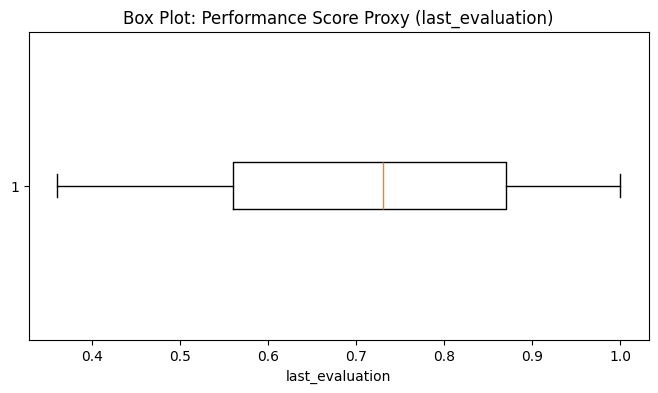

In [ ]:
# Box plot for performance score
plt.figure(figsize=(8, 4))
plt.boxplot(sampled_df["last_evaluation"], vert=False)
plt.title("Box Plot: Performance Score Proxy (last_evaluation)")
plt.xlabel("last_evaluation")
plt.show()


### **7 : One-Way ANOVA**
### Hypothesis: Do satisfaction scores differ across office locations?

**H0 (Null):** Mean satisfaction is same for all locations.

**H1 (Alternative):** At least one location has different mean satisfaction.

In [ ]:
# Group satisfaction levels by location
groups = [sampled_df[sampled_df["location"] == loc]["satisfaction_level"] for loc in sampled_df["location"].unique()]

# Run one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("One-way ANOVA (Satisfaction ~ Location)")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("✅ Reject H0: Satisfaction differs significantly across locations.")
else:
    print("❌ Fail to reject H0: No significant difference across locations.")


One-way ANOVA (Satisfaction ~ Location)
F-statistic = 2.3082
p-value     = 0.074492
❌ Fail to reject H0: No significant difference across locations.


### Tukey HSD Post-hoc Test (Location)
If ANOVA shows significance, Tukey test reveals **which specific pairs** differ.


In [ ]:
tukey_location = pairwise_tukeyhsd(
    endog=sampled_df["satisfaction_level"],
    groups=sampled_df["location"],
    alpha=0.05
)

print(tukey_location)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower   upper  reject
----------------------------------------------------------
Bangalore     Delhi   0.0189 0.2702  -0.008  0.0458  False
Bangalore Hyderabad   0.0023 0.9977 -0.0289  0.0334  False
Bangalore    Mumbai  -0.0061 0.9205 -0.0309  0.0186  False
    Delhi Hyderabad  -0.0166 0.5189 -0.0478  0.0146  False
    Delhi    Mumbai   -0.025 0.0478 -0.0499 -0.0002   True
Hyderabad    Mumbai  -0.0084 0.8833 -0.0378   0.021  False
----------------------------------------------------------


### **8 : Two-Way ANOVA (Department + Location + Interaction)**
### Hypothesis
**H0:** Department and Location do NOT affect satisfaction score.

**H1:** Department and/or Location significantly affect satisfaction.

Also check **interaction effect**:
- Does the impact of department depend on location?

In [ ]:
# Two-way ANOVA model with interaction
model = smf.ols("satisfaction_level ~ C(department) * C(location)", data=sampled_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Two-Way ANOVA Table (typ=2):")
display(anova_table)

# Interpretation helper
alpha = 0.05
for row in anova_table.index:
    p = anova_table.loc[row, "PR(>F)"]
    if p < alpha:
        print(f"✅ {row} is SIGNIFICANT (p={p:.6f})")
    else:
        print(f"❌ {row} is NOT significant (p={p:.6f})")


Two-Way ANOVA Table (typ=2):


,sum_sq,df,F,PR(>F)
C(department),0.502103,9.0,0.910106,0.515132
C(location),0.423481,3.0,2.302790,0.075028
C(department):C(location),1.713433,27.0,1.035250,0.413942
Residual,273.212768,4457.0,NaN,NaN


❌ C(department) is NOT significant (p=0.515132)
❌ C(location) is NOT significant (p=0.075028)
❌ C(department):C(location) is NOT significant (p=0.413942)
❌ Residual is NOT significant (p=nan)


### **9 : Department-wise Post Hoc (Tukey HSD)**
If department effect is significant, find which departments differ.

In [ ]:
tukey_dept = pairwise_tukeyhsd(
    endog=sampled_df["satisfaction_level"],
    groups=sampled_df["department"],
    alpha=0.05
)

print(tukey_dept)


     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj   lower  upper  reject
-------------------------------------------------------------
         IT       RandD   0.0308  0.897 -0.0346 0.0961  False
         IT  accounting  -0.0165 0.9987 -0.0824 0.0494  False
         IT          hr  -0.0046    1.0 -0.0714 0.0621  False
         IT  management   0.0246 0.9838 -0.0456 0.0948  False
         IT   marketing  -0.0032    1.0 -0.0669 0.0606  False
         IT product_mng    0.009    1.0 -0.0539 0.0718  False
         IT       sales   0.0027    1.0 -0.0439 0.0492  False
         IT     support   0.0084    1.0 -0.0425 0.0593  False
         IT   technical   0.0171 0.9847 -0.0321 0.0664  False
      RandD  accounting  -0.0473  0.556 -0.1199 0.0254  False
      RandD          hr  -0.0354 0.8819 -0.1088  0.038  False
      RandD  management  -0.0061    1.0 -0.0827 0.0704  False
      RandD   marketing  -0.0339 0.8846 -0.1046 0.0368  False
      Ra

### **10 : Key Findings Summary (Auto)**
This section summarizes the decisions based on p-values.

In [ ]:
summary = {}

# One-way
summary["one_way_location"] = {
    "F": f_stat,
    "p": p_value,
    "decision": "Reject H0" if p_value < 0.05 else "Fail to Reject H0"
}

# Two-way
summary["two_way_department_p"] = float(anova_table.loc["C(department)", "PR(>F)"])
summary["two_way_location_p"] = float(anova_table.loc["C(location)", "PR(>F)"])
summary["two_way_interaction_p"] = float(anova_table.loc["C(department):C(location)", "PR(>F)"])

summary


{'one_way_location': {'F': np.float64(2.3081835299959925),
  'p': np.float64(0.07449216551945208),
  'decision': 'Fail to Reject H0'},
 'two_way_department_p': 0.5151321485536622,
 'two_way_location_p': 0.07502821819322864,
 'two_way_interaction_p': 0.4139415510747228}

### **Conclusion :**
The practical demonstrated how statistical techniques like stratified sampling, outlier detection, and ANOVA help analyze factors affecting performance or satisfaction. It concluded that hypothesis testing effectively identifies whether department and location significantly influence employee scores.

### **Learning Outcomes :**


*   Gained understanding of applying stratified sampling to ensure representative datasets for analysis.
*   Learned to perform and interpret One-Way and Two-Way ANOVA, including hypothesis testing using p-values and F-statistics.
*   Developed skills in detecting outliers and analyzing group differences using post-hoc tests like Tukey’s HSD.


